# 2 Frequency Domain Analysis

## 2.1 As in Lab 1, we start by loading the file titled imperfect_sos_cw_700_15_wpm.wav, using the code fragment below.

In [35]:
import os
from scipy.io import wavfile

fs, x = wavfile.read(os.path.join('data','imperfect_sos_cw_700_15_wpm.wav'))
import IPython.display as ipd
ipd.display(ipd.Audio(data=x, rate=fs))

## 2.2 

In [36]:
import numpy as np


X = np.fft.fft(x,norm='forward')
F = np.fft.fftfreq(len(X), 1/fs)

## 2.3

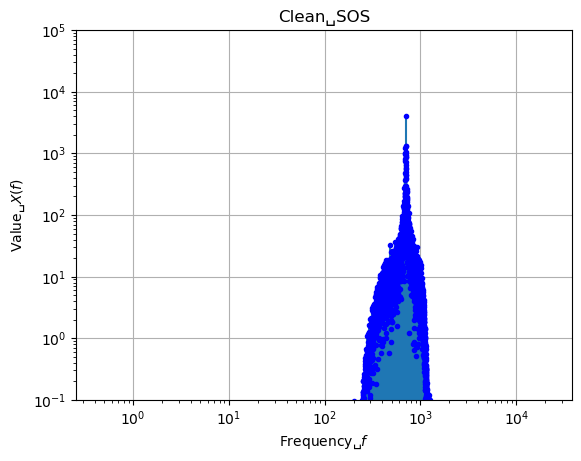

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.stem(np.fft.fftshift(F),np.fft.fftshift(np.abs(X)),markerfmt='b.')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-1,1e5)
plt.grid(True)
plt.xlabel('Frequency␣$f$')
plt.ylabel('Value␣$X(f)$')
plt.title('Clean␣SOS')
plt.show()

## 2.4 Comment on the observed frequency spectrum for the clean SOS signal. Can you use this to determine the frequency of the carrier wave?

From the diagram we can see the plots being concentrated at around 10^3. This consentration shows that the sound is quite clean. 

Using the graph we can see the carrier wave having a significantly higher value than the other freqnuencies, approximately in the middle of the consentration. 

## 2.5 Repeat this analysis for the noisy_sos_cw_700_15_wpm.wav file. Load the file and plot its frequency response in a comparable way to what we did earlier.

In [40]:
fs, y = wavfile.read(os.path.join('data','noisy_sos_cw_700_15_wpm.wav'))
ipd.display(ipd.Audio(data=y, rate=fs))

In [ ]:
Y = np.fft.fft(y,norm='forward')
F1 = np.fft.fftfreq(len(Y), 1/fs)


plt.figure()
plt.stem(np.fft.fftshift(F1),np.fft.fftshift(np.abs(Y)),markerfmt='b.')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-1,1e5)
plt.grid(True)
plt.xlabel('Frequency␣$f$')
plt.ylabel('Value␣$X(f)$')
plt.title('Noisy␣SOS')
plt.show()

## 2.6 Comment on the observed frequency spectrum for the noisy SOS signal. Can you say anything about the frequency characteristics of the noise?

In this graph there is no consentration at the carrier frequency. The values for the frequency do not have any distinct consentration or regularity. The only pronounced frequency is the carrier frequency which has a higher amplitude than any other frequency. The wide range of frequencies in this sound shows that there is a large amount of noise.

# 3 Frequency Domain Filtering

## 3.1 From the frequency responses observed, determine a suitable range of frequencies of interest to keep.

From the clean graph I will find the range of the condesed frequencies and keep that range.

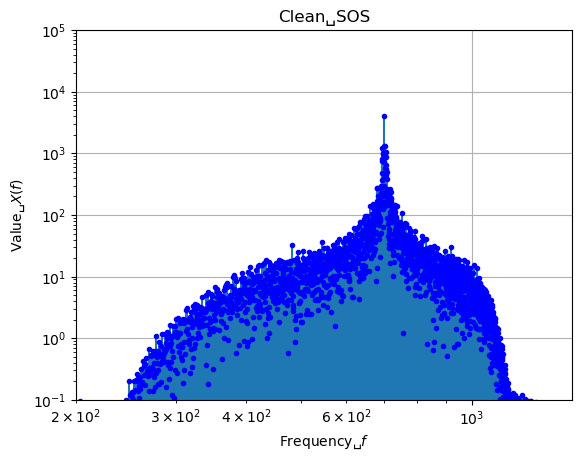

In [ ]:
plt.figure()
plt.stem(np.fft.fftshift(F),np.fft.fftshift(np.abs(X)),markerfmt='b.')
plt.xscale('log')
plt.yscale('log')
plt.xlim(200,1500)
plt.ylim(1e-1,1e5)
plt.grid(True)
plt.xlabel('Frequency␣$f$')
plt.ylabel('Value␣$X(f)$')
plt.title('Clean␣SOS')
plt.show()

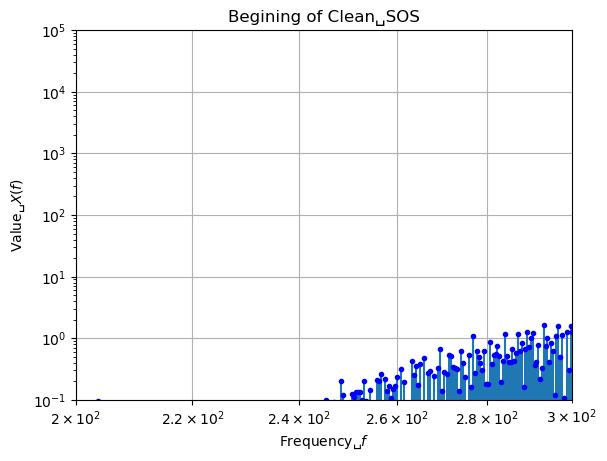

In [ ]:
plt.figure()
plt.stem(np.fft.fftshift(F),np.fft.fftshift(np.abs(X)),markerfmt='b.')
plt.xscale('log')
plt.yscale('log')
plt.xlim(200,300)
plt.ylim(1e-1,1e5)
plt.grid(True)
plt.xticks(np.arange(200, 300, step=20))
plt.xlabel('Frequency␣$f$')
plt.ylabel('Value␣$X(f)$')
plt.title('Begining of Clean␣SOS')
plt.show()

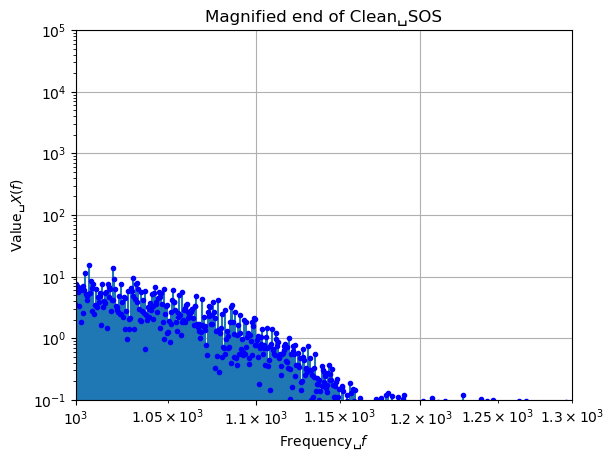

In [ ]:
plt.figure()
plt.stem(np.fft.fftshift(F),np.fft.fftshift(np.abs(X)),markerfmt='b.')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1000,1300)
plt.ylim(1e-1,1e5)
plt.grid(True)
plt.xticks(np.arange(1000, 1300, step=100))
plt.xlabel('Frequency␣$f$')
plt.ylabel('Value␣$X(f)$')
plt.title('Magnified end of Clean␣SOS')
plt.show()

The above graphs are zoomed in versions of the Clean␣SOS graph. From these graphs we can wee that the accumulation of points start from 240 and end at 1300. This will be the range of frequencies to keep.

## 3.2 Implement a frequency domain filter by discarding (zeroing out) the coefficients in X that correspond to frequencies F outside the range of interest. Plot the frequency response of the filtered signal.

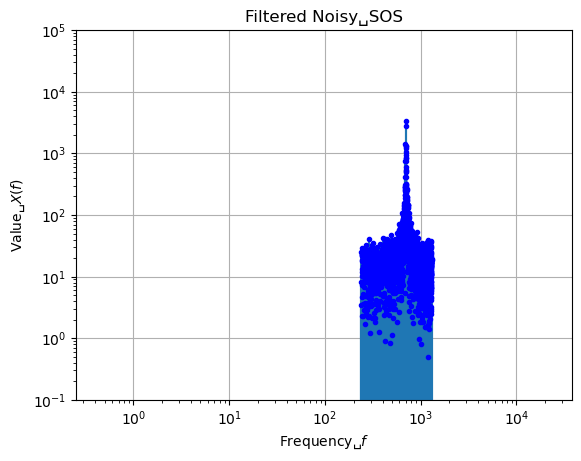

In [ ]:
i = 0
for n in F1:
    if n < 240 or n > 1300:
        Y[i] = 0
    i += 1


plt.figure()
plt.stem(np.fft.fftshift(F1),np.fft.fftshift(np.abs(Y)),markerfmt='b.')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-1,1e5)
plt.grid(True)
plt.xlabel('Frequency␣$f$')
plt.ylabel('Value␣$X(f)$')
plt.title('Filtered Noisy␣SOS')
plt.show()

## 3.3 Using the NumPy ifft function, from this filtered frequency response obtain the corresponding time‐domain signal. Hint: you are only interested in the real part of the result so if the inverse transform returns any imaginary component, this may be safely discarded.

In [ ]:
X_filtered = np.fft.ifft(Y)  
real_X_filtered = np.real(X_filtered)

## 3.4 Plot the time‐domain filtered signal in a similar way to what we did in Lab 􀅴, and comment on the result obtained.

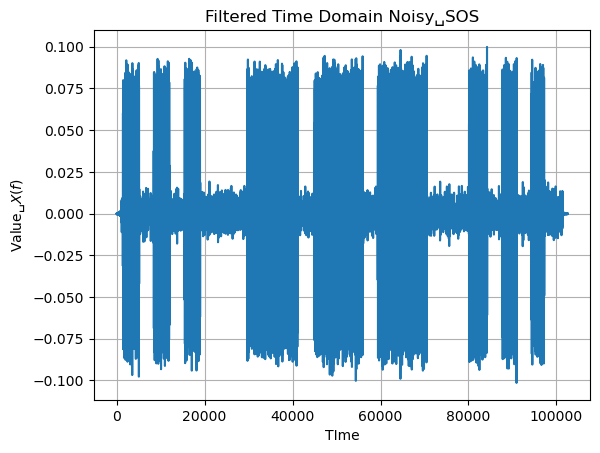

In [ ]:
plt.figure()
plt.plot(real_X_filtered)
plt.grid(True)
plt.xlabel('TIme')
plt.ylabel('Value␣$X(f)$')
plt.title('Filtered Time Domain Noisy␣SOS')
plt.show()

In this graph we can see there is minimal noise. Noise in the graph is present with small amplitude between the larger spikes. Compared to the important part of the sound, the amplitude of the noise is small. This suggests that the sound will be clearner as the filtering was succesful.

## 3.5 Play back the filtered signal and comment on the efficacy or otherwise of this approach.

In [41]:
ipd.display(ipd.Audio(data=real_X_filtered, rate=fs))

Compared to the starting sound of Noisy SOS, this sound clearer. The noise is way less loud and the morse code sounds more pronounced.